Problem Statement
To analyze Google play Store ecosystem to identify key factors influencing the app success. 

In [ ]:
Tho objective of this project is analyzing the google play store app data to identify the factores 
thet influnece the app success such as rating,reviews, category, downloads, developers, pricing and updates
etc... This Project helps developers to understand the user preference and market trends.these insights can assist developers 
in improving app quality, user engagement and make better business decisions. 

In [1]:
# import pandas as pd
# import time
# from google_play_scraper import search, app

# # Keywords to search
# keywords = [
#     "game","games","action","adventure","arcade","board","casino","casual",
#     "education","learning","math","science","books",
#     "business","office","finance","bank","investment",
#     "shopping","ecommerce","grocery","fashion",
#     "food","restaurant","recipe","delivery",
#     "health","fitness","medicine","doctor",
#     "music","audio","radio","podcast",
#     "photo","camera","gallery","editor",
#     "video","movie","player","streaming",
#     "travel","hotel","flight","maps",
#     "sports","cricket","football","tennis",
#     "social","chat","messenger","dating",
#     "news","magazine","weather",
#     "tools","utility","calculator","scanner",
#     "kids","parenting","art","design",
#     "beauty","lifestyle","productivity"
# ]

# # -----------------------------
# # Step 1: Search Apps
# # -----------------------------
# app_ids = set()

# for keyword in keywords:
#     print(f"Searching: {keyword}")

#     results = search(
#         keyword,
#         lang="en",
#         country="in",
#         n_hits=250
#     )

#     for r in results:
#         app_ids.add(r["appId"])

# print(f"\nTotal Unique Apps Found: {len(app_ids)}")

# # -----------------------------
# # Step 2: Fetch Details
# # -----------------------------
# data = []

# for i, app_id in enumerate(app_ids, start=1):

#     try:
#         details = app(
#             app_id,
#             lang="en",
#             country="in"
#         )

#         data.append({
#             "App Name": details.get("title"),
#             "Rating": details.get("score"),
#             "Reviews": details.get("reviews"),
#             "Downloads": details.get("installs"),
#             "Price": details.get("price"),
#             "Category": details.get("genre"),
#             "Developer": details.get("developer"),
#             "Last Updated": details.get("updated"),
#             "Version": details.get("version"),
#             "Size": details.get("size")
#         })

#         print(f"{i}. {details.get('title')}")

#         time.sleep(0.3)

#     except Exception as e:
#         print(f"Skipped {app_id} -> {e}")

# # -----------------------------
# # Step 3: Save CSV
# # -----------------------------
# df = pd.DataFrame(data)

# df.to_csv("Apps.csv", index=False)

# print("\nDone!")
# print(df.head())
# print("Total Apps:", len(df))

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("Apps.csv")
data

,App Name,Rating,Reviews,Downloads,Price,Category,Developer,Last Updated,Version,Size
0,Steam,3.513619,5378.0,"100,000,000+",0.0,Entertainment,Valve Corporation,1.772741e+09,3.10.9,NaN
1,Blub,NaN,NaN,"1,000+",0.0,Education,Bamu Teknoloji A.Ş.,NaN,Varies with device,NaN
2,FunLab,3.809524,1.0,"10,000+",0.0,Education,The Dad Lab,1.773332e+09,3.260312.0,NaN
3,JustWatch,3.556274,1608.0,"10,000,000+",0.0,Entertainment,JustWatch GmbH,1.785186e+09,Varies with device,NaN
4,Milkbasket,4.200701,48810.0,"5,000,000+",0.0,Shopping,Milkbasket,1.783356e+09,9.0.2,NaN
...,...,...,...,...,...,...,...,...,...,...
486,Elevate,4.563207,13431.0,"10,000,000+",0.0,Education,The Mind Company,1.785089e+09,5.250.0,NaN
487,Toki,3.019417,75.0,"5,000,000+",0.0,Social,HappyMingle Team,1.784801e+09,1.4.6,NaN
488,CarryMap,4.368421,2.0,"100,000+",0.0,Maps & Navigation,XTools Pro,1.782725e+09,7.2,NaN
489,Behance,4.656891,4297.0,"10,000,000+",0.0,Art & Design,Adobe Inc,1.784055e+09,26.714.1233,NaN


In [4]:
data["App Name"].nunique()

470

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   App Name      491 non-null    object 
 1   Rating        473 non-null    float64
 2   Reviews       473 non-null    float64
 3   Downloads     491 non-null    object 
 4   Price         491 non-null    float64
 5   Category      491 non-null    object 
 6   Developer     491 non-null    object 
 7   Last Updated  472 non-null    float64
 8   Version       491 non-null    object 
 9   Size          0 non-null      float64
dtypes: float64(5), object(5)
memory usage: 38.5+ KB


In [6]:
data.describe()

,Rating,Reviews,Price,Last Updated,Size
count,473.000000,4.730000e+02,491.000000,4.720000e+02,0.0
mean,4.283284,1.855673e+05,10.301426,1.781780e+09,NaN
std,0.393678,8.020240e+05,225.649075,1.084759e+07,NaN
min,2.082888,0.000000e+00,0.000000,1.675663e+09,NaN
25%,4.095146,5.810000e+02,0.000000,1.783358e+09,NaN
50%,4.367594,6.178000e+03,0.000000,1.784559e+09,NaN
75%,4.564118,4.340500e+04,0.000000,1.784895e+09,NaN
max,5.000000,1.145765e+07,5000.000000,1.785219e+09,NaN


In [7]:
# Name Column , we found some names with unknown language , and with some different symbols 
# so we droped those rows

In [8]:
data = data[
    ~data["App Name"].str.contains(r"[™®]|[^\x00-\x7F]", regex=True, na=False)
].reset_index(drop=True)

In [9]:
data.shape

(485, 10)

In [10]:
data.duplicated().sum()
# no duplicated rows

np.int64(0)

In [11]:
data["App Name"].duplicated().value_counts()

App Name
False    464
True      21
Name: count, dtype: int64

In [12]:
data[data.isnull().all(axis=1)]
# zero rows with all nulls

,App Name,Rating,Reviews,Downloads,Price,Category,Developer,Last Updated,Version,Size


In [13]:
data.isnull().sum()

App Name          0
Rating           18
Reviews          18
Downloads         0
Price             0
Category          0
Developer         0
Last Updated     19
Version           0
Size            485
dtype: int64

In [14]:
# Treating nulls in Rating Column


In [15]:
data['Category'].nunique()

35

In [16]:
# The apps were grouped by their category, and the average rating of each category was calculated. 
#     Missing ratings were then replaced with the average rating of their respective category.

In [17]:
data["Rating"] = data["Rating"].fillna(
    data.groupby("Category")["Rating"].transform("median")
)

In [18]:
data["Rating"].isnull().sum()

np.int64(0)

In [19]:
data.describe()

,Rating,Reviews,Price,Last Updated,Size
count,485.000000,4.670000e+02,485.000000,4.660000e+02,0.0
mean,4.287672,1.866822e+05,10.428866,1.781791e+09,NaN
std,0.385462,8.067289e+05,227.040485,1.091281e+07,NaN
min,2.082888,0.000000e+00,0.000000,1.675663e+09,NaN
25%,4.102492,5.875000e+02,0.000000,1.783425e+09,NaN
50%,4.370370,6.355000e+03,0.000000,1.784571e+09,NaN
75%,4.564118,4.385500e+04,0.000000,1.784897e+09,NaN
max,5.000000,1.145765e+07,5000.000000,1.785219e+09,NaN


In [20]:
data["Reviews"] = data["Reviews"].fillna(
    data.groupby("Category")["Reviews"].transform("median")
)

In [21]:
data["Reviews"].isnull().sum()

np.int64(0)

In [22]:
data["Rating"] = data["Rating"].round(1)
data["Rating"]

0      3.5
1      4.5
2      3.8
3      3.6
4      4.2
      ... 
480    4.6
481    3.0
482    4.4
483    4.7
484    4.9
Name: Rating, Length: 485, dtype: float64

In [23]:
data["Reviews"]=data["Reviews"].astype("int")

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   App Name      485 non-null    object 
 1   Rating        485 non-null    float64
 2   Reviews       485 non-null    int64  
 3   Downloads     485 non-null    object 
 4   Price         485 non-null    float64
 5   Category      485 non-null    object 
 6   Developer     485 non-null    object 
 7   Last Updated  466 non-null    float64
 8   Version       485 non-null    object 
 9   Size          0 non-null      float64
dtypes: float64(4), int64(1), object(5)
memory usage: 38.0+ KB


In [25]:
data["Downloads"] = data["Downloads"].str.replace("+", "").str.replace(",","", regex=False)
data["Downloads"] = data["Downloads"].astype('int')

In [26]:
data["Last Updated"] = pd.to_datetime(data["Last Updated"], unit="s")

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   App Name      485 non-null    object        
 1   Rating        485 non-null    float64       
 2   Reviews       485 non-null    int64         
 3   Downloads     485 non-null    int64         
 4   Price         485 non-null    float64       
 5   Category      485 non-null    object        
 6   Developer     485 non-null    object        
 7   Last Updated  466 non-null    datetime64[ns]
 8   Version       485 non-null    object        
 9   Size          0 non-null      float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 38.0+ KB


In [28]:
data

,App Name,Rating,Reviews,Downloads,Price,Category,Developer,Last Updated,Version,Size
0,Steam,3.5,5378,100000000,0.0,Entertainment,Valve Corporation,2026-03-05 19:59:35,3.10.9,NaN
1,Blub,4.5,5748,1000,0.0,Education,Bamu Teknoloji A.Ş.,NaT,Varies with device,NaN
2,FunLab,3.8,1,10000,0.0,Education,The Dad Lab,2026-03-12 16:12:07,3.260312.0,NaN
3,JustWatch,3.6,1608,10000000,0.0,Entertainment,JustWatch GmbH,2026-07-27 21:02:58,Varies with device,NaN
4,Milkbasket,4.2,48810,5000000,0.0,Shopping,Milkbasket,2026-07-06 16:43:53,9.0.2,NaN
...,...,...,...,...,...,...,...,...,...,...
480,Elevate,4.6,13431,10000000,0.0,Education,The Mind Company,2026-07-26 17:57:05,5.250.0,NaN
481,Toki,3.0,75,5000000,0.0,Social,HappyMingle Team,2026-07-23 10:08:54,1.4.6,NaN
482,CarryMap,4.4,2,100000,0.0,Maps & Navigation,XTools Pro,2026-06-29 09:22:27,7.2,NaN
483,Behance,4.7,4297,10000000,0.0,Art & Design,Adobe Inc,2026-07-14 18:54:49,26.714.1233,NaN


In [29]:
data["Last Updated"] = data["Last Updated"].fillna(
    data.groupby("Category")["Last Updated"].transform("median")
)

In [30]:
# Size Column has all Nans  
# so better to remove the column because there is no need of keeping it

In [31]:
data.drop("Size",axis=1,inplace = True)

In [32]:
data

,App Name,Rating,Reviews,Downloads,Price,Category,Developer,Last Updated,Version
0,Steam,3.5,5378,100000000,0.0,Entertainment,Valve Corporation,2026-03-05 19:59:35,3.10.9
1,Blub,4.5,5748,1000,0.0,Education,Bamu Teknoloji A.Ş.,2026-07-16 06:55:35,Varies with device
2,FunLab,3.8,1,10000,0.0,Education,The Dad Lab,2026-03-12 16:12:07,3.260312.0
3,JustWatch,3.6,1608,10000000,0.0,Entertainment,JustWatch GmbH,2026-07-27 21:02:58,Varies with device
4,Milkbasket,4.2,48810,5000000,0.0,Shopping,Milkbasket,2026-07-06 16:43:53,9.0.2
...,...,...,...,...,...,...,...,...,...
480,Elevate,4.6,13431,10000000,0.0,Education,The Mind Company,2026-07-26 17:57:05,5.250.0
481,Toki,3.0,75,5000000,0.0,Social,HappyMingle Team,2026-07-23 10:08:54,1.4.6
482,CarryMap,4.4,2,100000,0.0,Maps & Navigation,XTools Pro,2026-06-29 09:22:27,7.2
483,Behance,4.7,4297,10000000,0.0,Art & Design,Adobe Inc,2026-07-14 18:54:49,26.714.1233


In [33]:
# Nearly all apps in the dataset are free (Price = 0.0). Only three apps are paid, with prices of 29.0 and 5000.0,
# indicating that paid applications are rare compared to free applications on the Google Play Store.

In [34]:
data["Version"].nunique()

380

In [35]:
data[data["Version"]=="Varies with device"].count()

App Name        93
Rating          93
Reviews         93
Downloads       93
Price           93
Category        93
Developer       93
Last Updated    93
Version         93
dtype: int64

In [36]:
data.isnull().sum()

App Name        0
Rating          0
Reviews         0
Downloads       0
Price           0
Category        0
Developer       0
Last Updated    0
Version         0
dtype: int64

In [37]:
data.shape

(485, 9)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   App Name      485 non-null    object        
 1   Rating        485 non-null    float64       
 2   Reviews       485 non-null    int64         
 3   Downloads     485 non-null    int64         
 4   Price         485 non-null    float64       
 5   Category      485 non-null    object        
 6   Developer     485 non-null    object        
 7   Last Updated  485 non-null    datetime64[ns]
 8   Version       485 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 34.2+ KB


In [36]:
data.describe()

,Rating,Reviews,Downloads,Price,Last Updated
count,485.000000,4.850000e+02,4.850000e+02,485.000000,485
mean,4.290515,1.799550e+05,1.988923e+08,10.428866,2026-06-19 16:36:34.532989696
min,2.100000,0.000000e+00,1.000000e+00,0.000000,2023-02-06 06:01:54
25%,4.100000,6.310000e+02,5.000000e+06,0.000000,2026-07-07 23:35:47.500000
50%,4.400000,5.988000e+03,1.000000e+07,0.000000,2026-07-20 14:42:43
75%,4.600000,3.979100e+04,1.000000e+08,0.000000,2026-07-24 10:51:46
max,5.000000,1.145765e+07,1.000000e+10,5000.000000,2026-07-28 06:15:56
std,0.386595,7.923290e+05,9.747677e+08,227.040485,NaN


In [37]:
# The Version column contained 93 records with the value "Varies with device". 
# This is a valid Google Play Store value indicating that the app version differs across devices. 
# Therefore, these values were retained and not treated as missing data.

# Univaraite Anaysis


1. App Name

In [38]:
print("Total Apps :", data["App Name"].count())
print("Unique Apps :", data["App Name"].nunique())
print("Duplicate Apps :", data["App Name"].duplicated().sum())

Total Apps : 485
Unique Apps : 464
Duplicate Apps : 21


In [39]:
# The App Name column contains 21 duplicate app names. However, upon further analysis, 
# these records were found to belong to different developers and/or different categories. 
# Therefore, they represent distinct applications rather than duplicate records. As a result, no records were removed from the dataset.

2. Rating

In [40]:
data["Rating"].describe()

count    485.000000
mean       4.290515
std        0.386595
min        2.100000
25%        4.100000
50%        4.400000
75%        4.600000
max        5.000000
Name: Rating, dtype: float64

<Axes: >

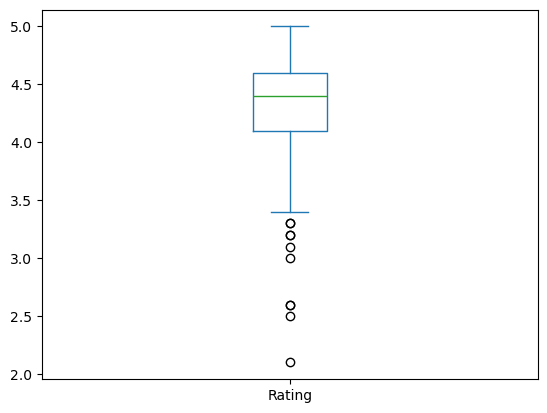

In [41]:
data["Rating"].plot(kind='box')

In [42]:
# "The outliers are genuine app ratings, not incorrect values.
# Removing them would discard valid information and could bias the analysis. Therefore, I retained them."

In [43]:
data["Rating"].mode()

0    4.5
Name: Rating, dtype: float64

In [44]:
bins = [0, 2, 3, 4, 5]
labels = ["Poor", "Average", "Good", "Excellent"]

data["Rating_Group"] = pd.cut(
    data["Rating"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(data["Rating_Group"].value_counts())

Rating_Group
Excellent    379
Good         101
Average        5
Poor           0
Name: count, dtype: int64


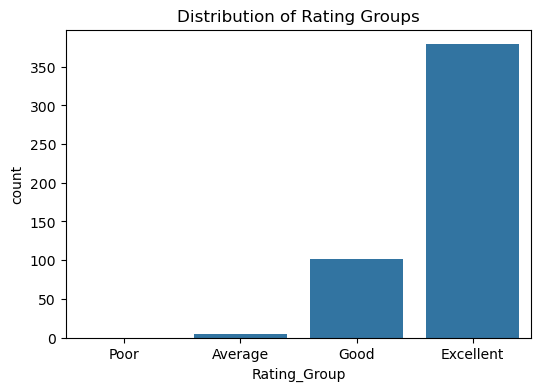

In [78]:
import seaborn as sns
plt.figure(figsize=(6,4))

sns.countplot(
    x="Rating_Group",
    data=data,
    order=["Poor","Average","Good","Excellent"]
)

plt.title("Distribution of Rating Groups")

plt.show()

In [ ]:
The majority of apps on the Google Play Store have Excellent ratings, 
indicating that most apps provide a satisfactory user experience and receive positive feedback from users.

In [ ]:
data["Rating_Group"].value_counts(normalize=True)*100

In [ ]:
data["Rating"].skew()

In [ ]:
# The Rating distribution is highly left-skewed (skewness = -1.55), with most apps receiving ratings above 4.0. 
# This indicates a generally high level of user satisfaction, while only a few apps have low ratings.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data["Rating"], bins=10, edgecolor="black")
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [ ]:
percentage = (data["Rating"] >= 4.0).mean() * 100
print(f"Percentage of apps with rating >= 4.0: {percentage:.2f}%")

In [46]:
#  Approximately 84% of  apps have ratings above 4.0, indicating positive user satisfaction.
# Low-rated apps are rare, and the distribution is slightly left-skewed due to a small number of apps with lower ratings.

3. Reviews

In [47]:
data["Reviews"].describe()

count    4.850000e+02
mean     1.799550e+05
std      7.923290e+05
min      0.000000e+00
25%      6.310000e+02
50%      5.988000e+03
75%      3.979100e+04
max      1.145765e+07
Name: Reviews, dtype: float64

In [48]:
data["Reviews"].skew()

np.float64(9.52770672088707)

In [49]:
# The Reviews column is highly positively (right) skewed (skewness = 9.52). 
# This means that most apps have fewer reviews, while a small number of apps have exceptionally high review counts.

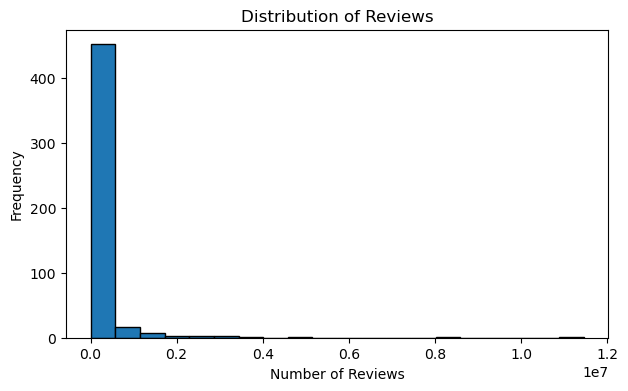

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(data["Reviews"], bins=20, edgecolor="black")
plt.title("Distribution of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

4. Downloads

In [52]:
data["Downloads"].describe()

count    4.850000e+02
mean     1.988923e+08
std      9.747677e+08
min      1.000000e+00
25%      5.000000e+06
50%      1.000000e+07
75%      1.000000e+08
max      1.000000e+10
Name: Downloads, dtype: float64

<Axes: >

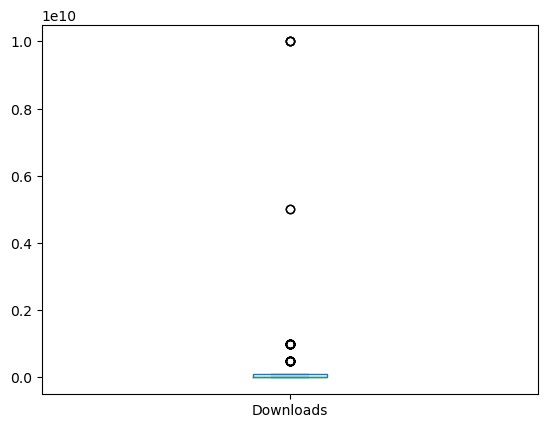

In [53]:
data["Downloads"].plot(kind='box')

In [55]:
top10_downloads = data.sort_values(by="Downloads", ascending=False).head(10)

top10_downloads[["App Name", "Category", "Downloads", "Rating"]]

,App Name,Category,Downloads,Rating
195,YouTube,Video Players & Editors,10000000000,4.1
38,Gboard,Tools,10000000000,4.4
67,Facebook,Social,10000000000,4.4
416,Google,Tools,10000000000,4.3
394,Messenger,Communication,5000000000,4.4
11,Instagram,Social,5000000000,4.3
301,LinkedIn,Business,1000000000,4.1
468,ChatGPT,Productivity,1000000000,4.5
437,Uber,Maps & Navigation,1000000000,4.7
168,Weather,Weather,1000000000,4.0


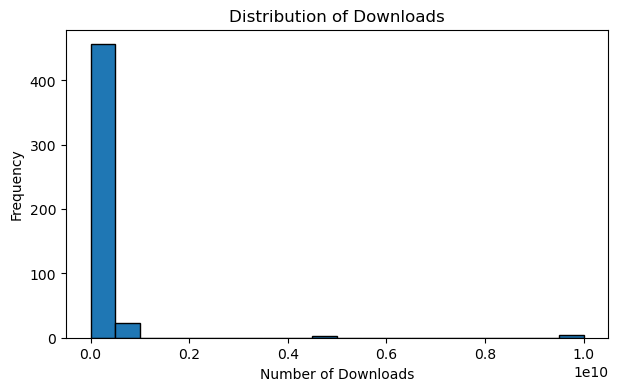

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(data["Downloads"], bins=20, edgecolor="black")
plt.title("Distribution of Downloads")
plt.xlabel("Number of Downloads")
plt.ylabel("Frequency")
plt.show()

# 5. Price

In [58]:
data["Price"].describe()

count     485.000000
mean       10.428866
std       227.040485
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      5000.000000
Name: Price, dtype: float64

In [59]:
data[data["Price"] != 0][["App Name","Price"]]

,App Name,Price
240,Minecraft,29.0
243,RFS,29.0
333,OsmAnd,5000.0


# 6. Category

In [61]:
data["Category"].value_counts()

Category
Travel & Local             38
Shopping                   35
Education                  33
Food & Drink               31
Music & Audio              25
Social                     25
Entertainment              24
Productivity               22
Finance                    22
Health & Fitness           19
Tools                      18
Business                   18
News & Magazines           17
Sports                     17
Medical                    16
Photography                15
Video Players & Editors    15
Communication              13
Weather                    11
Lifestyle                  10
Dating                      9
Maps & Navigation           9
Art & Design                8
Books & Reference           6
Board                       5
Simulation                  4
Parenting                   4
Casual                      4
Casino                      2
Arcade                      2
Action                      2
Educational                 2
Puzzle                      2
A

In [62]:
print("Number of Categories:", data["Category"].nunique())

Number of Categories: 35


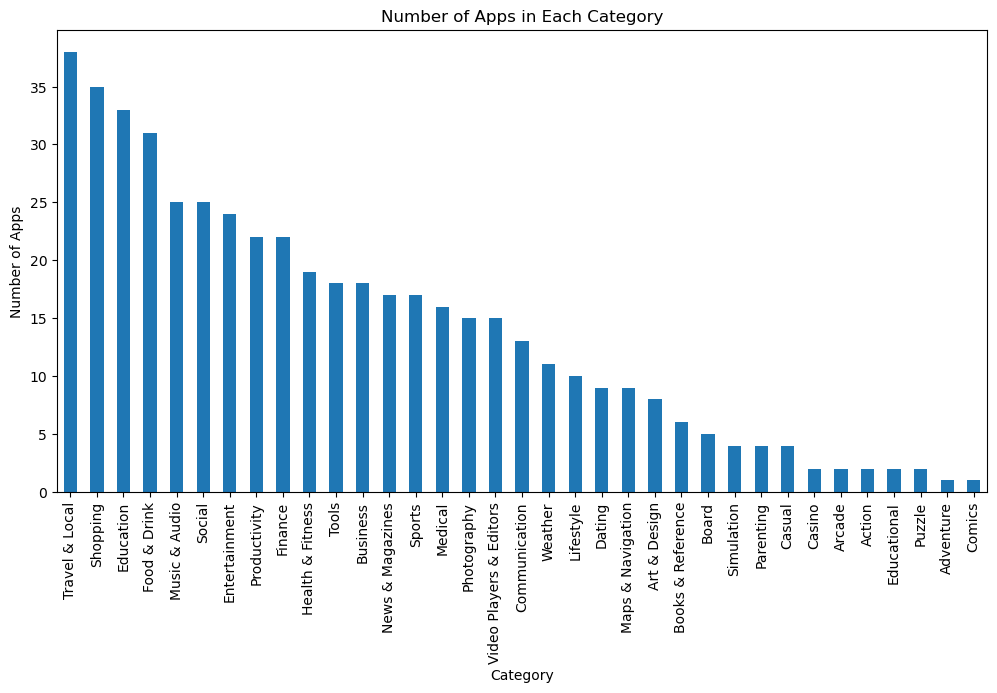

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
data["Category"].value_counts().plot(kind="bar")
plt.title("Number of Apps in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.show()

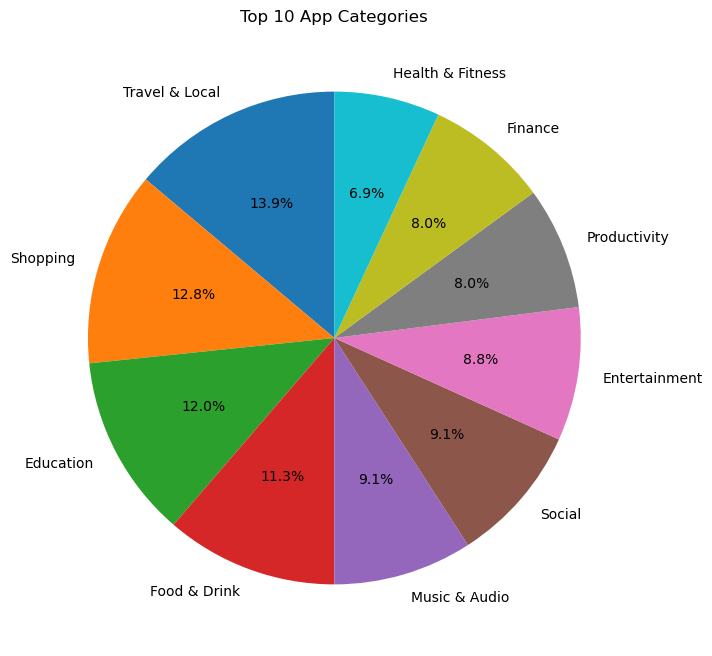

In [66]:
top10 = data["Category"].value_counts().head(10)

top10.plot(
    kind="pie",
    figsize=(8,8),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 App Categories")
plt.ylabel("")
plt.show()


# 7. Developers

In [241]:
# Top 10 Developers
top_developers = data["Developer"].value_counts().head(10)

print(top_developers)

Developer
Google LLC                         9
Instagram                          3
Swiggy                             3
Xiaomi Inc.                        2
Jio Platforms Limited              2
Naver Z Corporation                2
PINGUO TECHNOLOGY HK CO LIMITED    2
VKL                                2
ColorOS                            2
Blinkit                            2
Name: count, dtype: int64


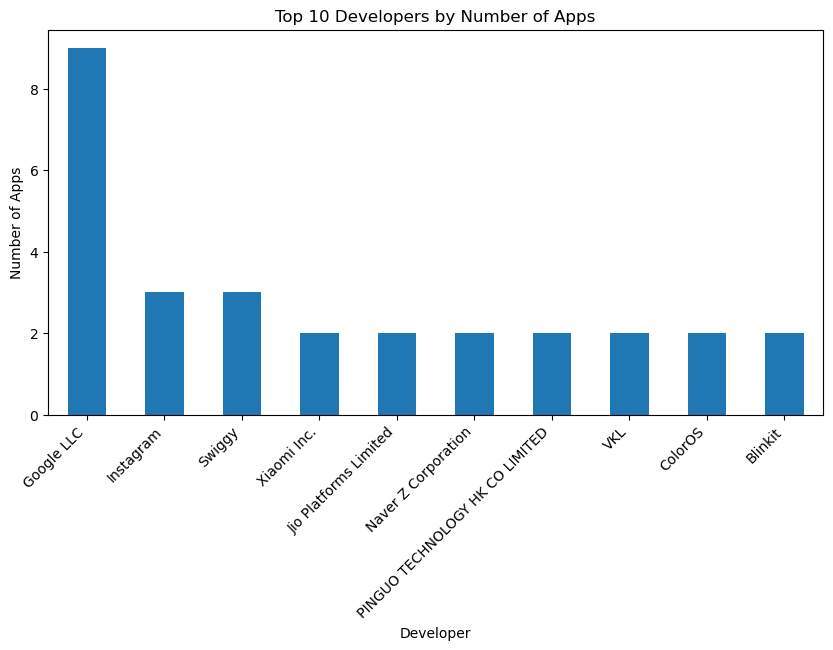

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_developers.plot(kind="bar")
plt.title("Top 10 Developers by Number of Apps")
plt.xlabel("Developer")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45, ha="right")
plt.show()

# 9. Version

In [243]:
top_versions = data["Version"].value_counts().head(10)

print(top_versions)

Version
Varies with device    93
1.2.0                  3
2026.29.0              2
4.113.1                2
26.6.0                 2
3.3.6                  2
14.26.0                2
5.3.10                 2
3.1.2                  2
8.3.0                  2
Name: count, dtype: int64


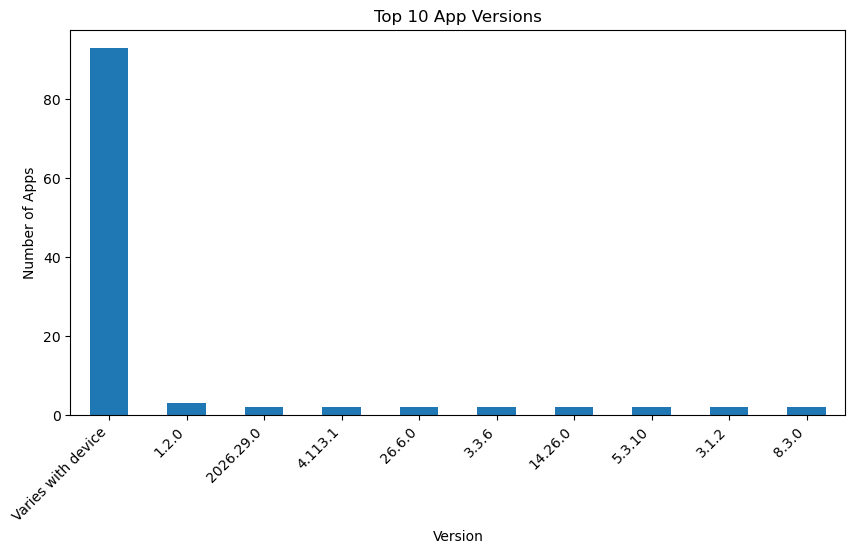

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_versions.plot(kind="bar")
plt.title("Top 10 App Versions")
plt.xlabel("Version")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45, ha="right")
plt.show()

In [245]:
# The Version column contains many different app versions. The value "Varies with device" is the most common,
# indicating that these apps provide different versions depending on the user's device. 
# All other version numbers appear only a few times, showing that most apps have their own unique versions.

# Bivariate Analysis

# 1.Category vs Rating
# To identify which app categories receive higher or lower user ratings.

In [246]:
avg_rating = data.groupby("Category")["Rating"].mean().sort_values(ascending=False)

avg_rating

Category
Adventure                  4.600000
Parenting                  4.500000
Food & Drink               4.454839
Finance                    4.450000
Education                  4.439394
Productivity               4.436364
Lifestyle                  4.430000
Travel & Local             4.428947
Medical                    4.418750
Board                      4.380000
Books & Reference          4.366667
Photography                4.353333
Casual                     4.350000
Maps & Navigation          4.311111
Health & Fitness           4.310526
Comics                     4.300000
Art & Design               4.300000
Sports                     4.300000
News & Magazines           4.282353
Video Players & Editors    4.280000
Music & Audio              4.276000
Tools                      4.266667
Arcade                     4.250000
Shopping                   4.231429
Business                   4.216667
Simulation                 4.175000
Action                     4.150000
Educational        

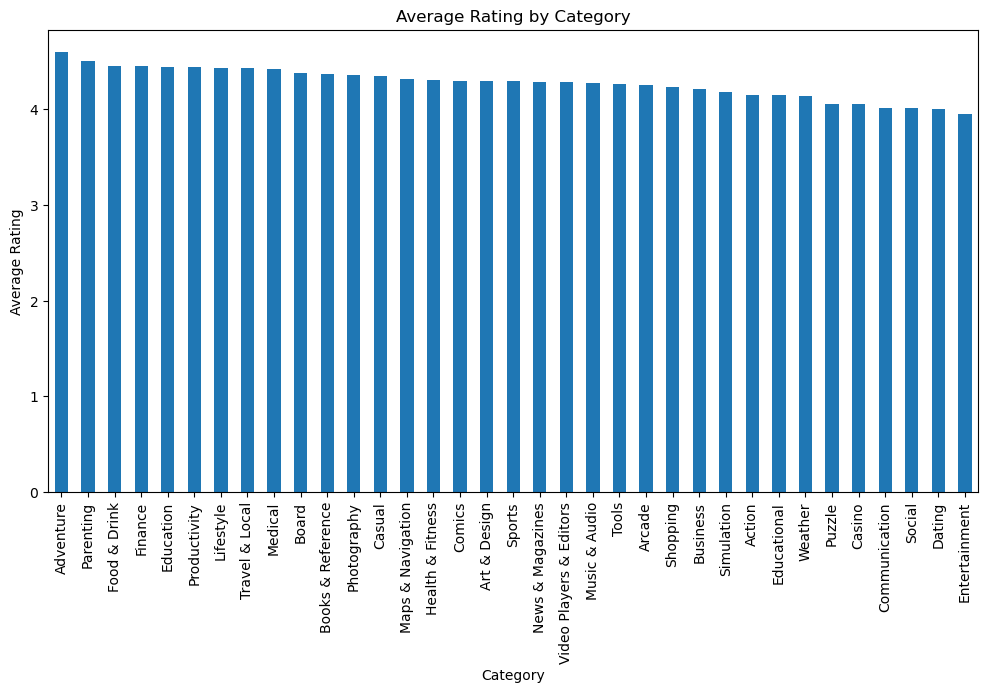

In [247]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

avg_rating.plot(kind="bar")

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)

plt.show()

In [248]:
# Most app categories have an average rating above 4.0. 
# Adventure has the highest average rating, while Entertainment has the lowest. Overall, user ratings are similar across all categories.

# Downloads vs price

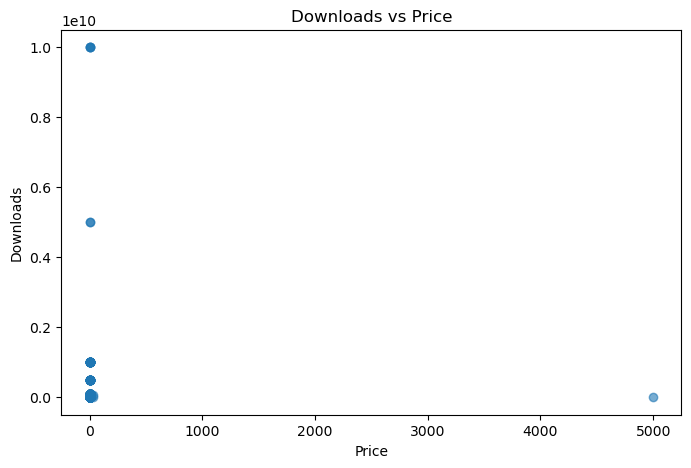

In [249]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(data["Price"], data["Downloads"], alpha=0.6)

plt.title("Downloads vs Price")
plt.xlabel("Price")
plt.ylabel("Downloads")

plt.show()

In [ ]:
Free apps dominate the Play Store in terms of downloads. Paid apps, especially high-priced ones, attract significantly fewer users.
This indicates that pricing plays an important role in influencing app downloads.

# 2. Category vs Downloads

# Why?
 # To compare which app categories have the highest average downloads.

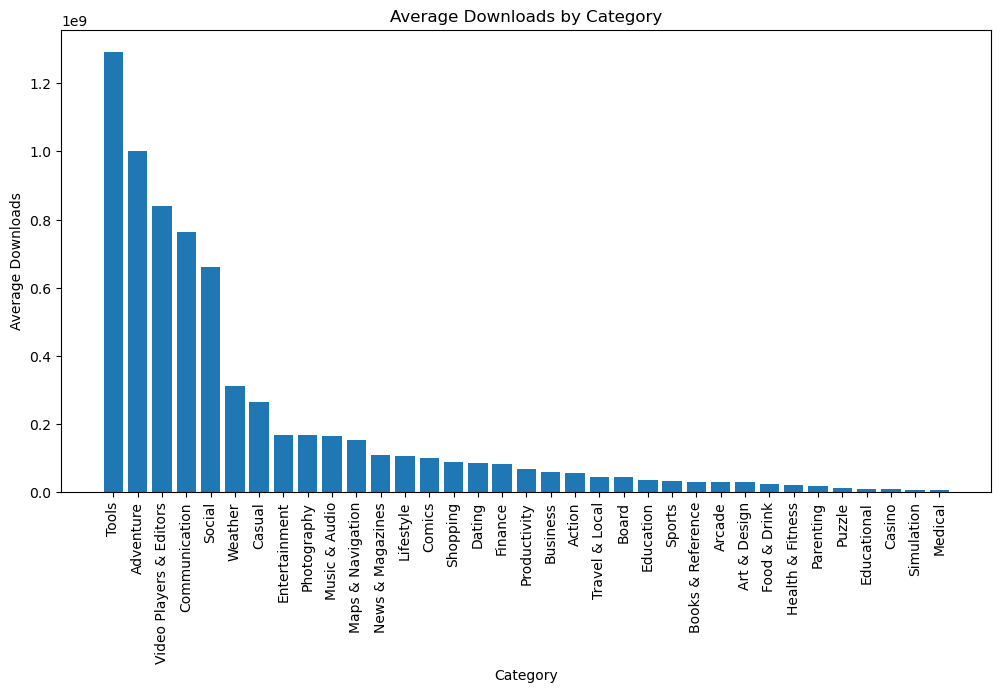

In [250]:
avg_downloads = data.groupby("Category")["Downloads"].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(avg_downloads.index, avg_downloads.values)
plt.title("Average Downloads by Category")
plt.xlabel("Category")
plt.ylabel("Average Downloads")
plt.xticks(rotation=90)
plt.show()

In [251]:
# The bar chart shows that the Tools category has the highest average downloads, 
# while the Medical category has the lowest average downloads. This indicates that app downloads vary across different categories.

# 3. Category vs Reviews
Why?

To compare the average number of reviews across different app categories.

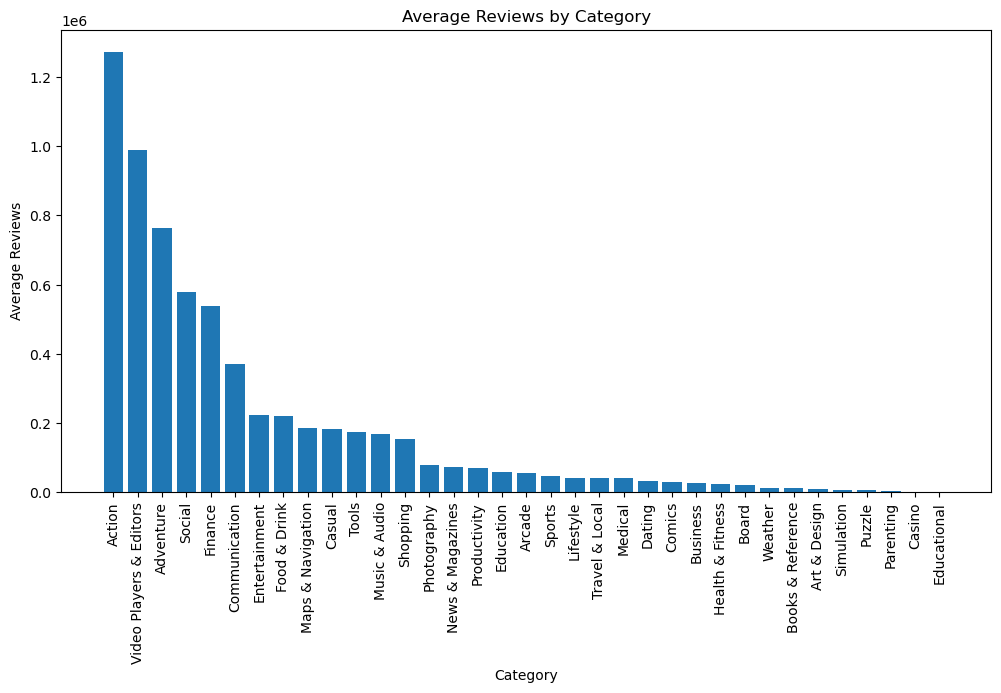

In [252]:
avg_reviews = data.groupby("Category")["Reviews"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(avg_reviews.index, avg_reviews.values)

plt.title("Average Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Average Reviews")
plt.xticks(rotation=90)

plt.show()

In [253]:
# The bar chart shows that the Action category has the highest average number of reviews, while the Educational category has the lowest average number of reviews. 
    # This indicates that user reviews vary across different app categories.

# 4.Price vs Rating

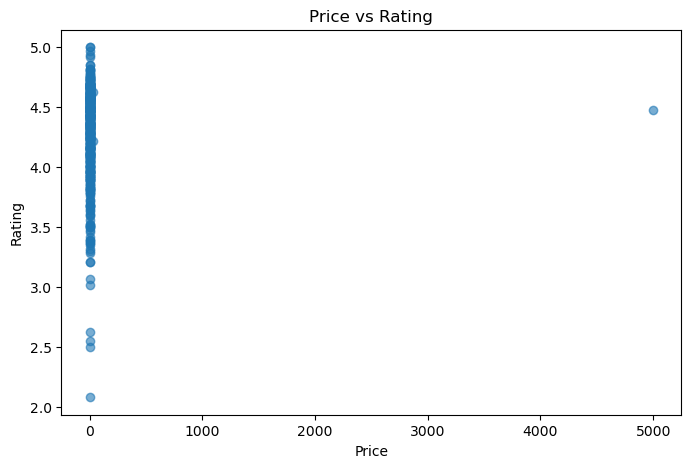

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(data["Price"], data["Rating"], alpha=0.6)

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

In [ ]:
The scatter plot indicates that there is no strong relationship between app price
and user rating. Most apps in the dataset are free and generally receive high ratings.
Due to the very small number of paid apps, it is not possible to conclude that price significantly influences app ratings.

In [254]:
# Most apps in the dataset are free, while only three apps are paid. Since the number of paid apps is very small, 
# a meaningful comparison between price and rating cannot be made. Therefore, this relationship was not analyzed further.

# 5. Downloads vs Reviews

In [255]:
# Why?
# To check whether apps with more downloads also receive more reviews.

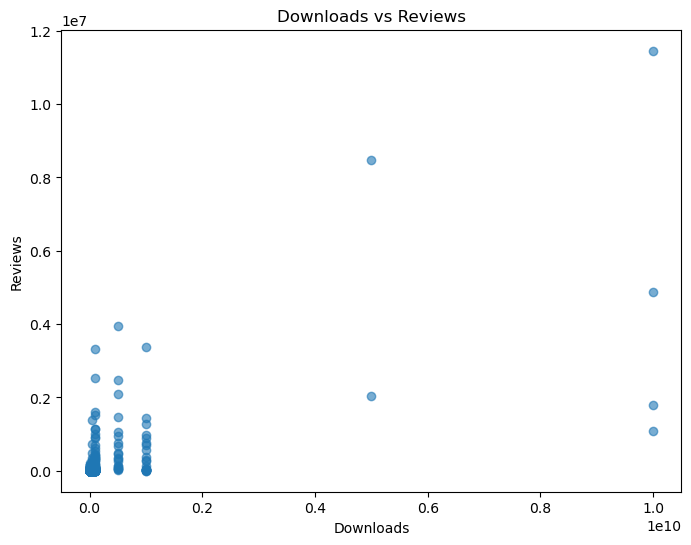

In [256]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(data["Downloads"], data["Reviews"], alpha=0.6)

plt.title("Downloads vs Reviews")
plt.xlabel("Downloads")
plt.ylabel("Reviews")

plt.show()

In [257]:
The scatter plot shows a positive relationship between downloads and reviews.
Apps with more downloads generally receive more reviews.

# Downloads vs Ratings 

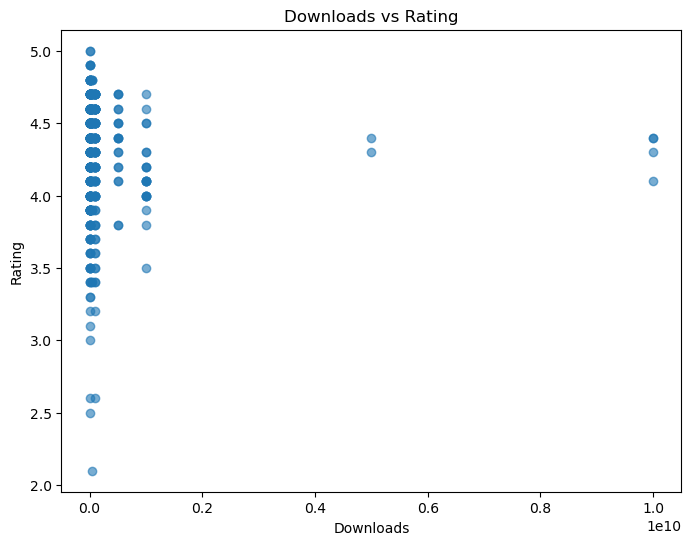

In [258]:
plt.figure(figsize=(8,6))

plt.scatter(data["Downloads"], data["Rating"], alpha=0.6)

plt.title("Downloads vs Rating")
plt.xlabel("Downloads")
plt.ylabel("Rating")

plt.show()

In [259]:
# The scatter plot shows that apps with more downloads usually have good ratings. 
# However, apps with fewer downloads can also have good ratings. Therefore, the number of downloads does not have a strong effect on an app's rating.

# Reviews vs Rating

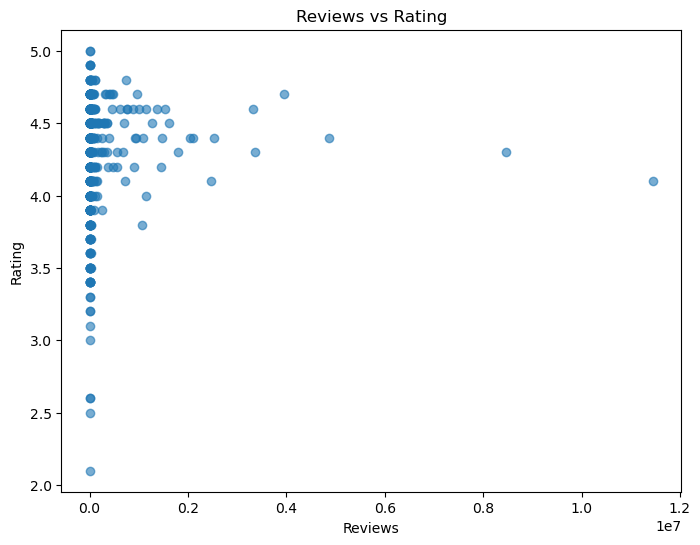

In [260]:
plt.figure(figsize=(8,6))

plt.scatter(data["Reviews"], data["Rating"], alpha=0.6)

plt.title("Reviews vs Rating")
plt.xlabel("Reviews")
plt.ylabel("Rating")

plt.show()

In [261]:
# The scatter plot shows that apps with more reviews generally have good ratings. However, apps with fewer reviews can also have high ratings. 
    # This indicates that the number of reviews does not strongly affect an app's rating.

# Last updated vs Ratings

In [262]:
# To check whether recently updated apps have better ratings.

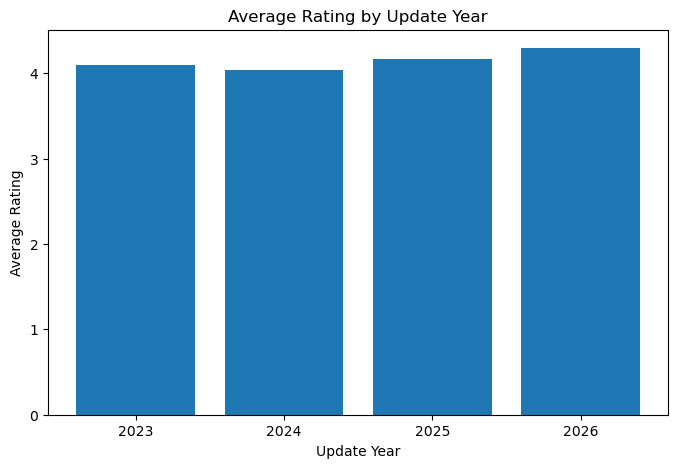

In [263]:
data["Update Year"] = data["Last Updated"].dt.year
avg_rating = data.groupby("Update Year")["Rating"].mean().sort_index()

plt.figure(figsize=(8,5))
plt.bar(avg_rating.index.astype(str), avg_rating.values)

plt.title("Average Rating by Update Year")
plt.xlabel("Update Year")
plt.ylabel("Average Rating")

plt.show()

In [264]:
# The bar chart shows that the average rating is above 4.0 for all update years. Apps updated in 2026 have the highest average rating, while apps updated in 2024 have the lowest average rating. 
    # Overall, the difference in ratings across years is small.

# Multivaraite Analysis

# Category, Downloads, Rating

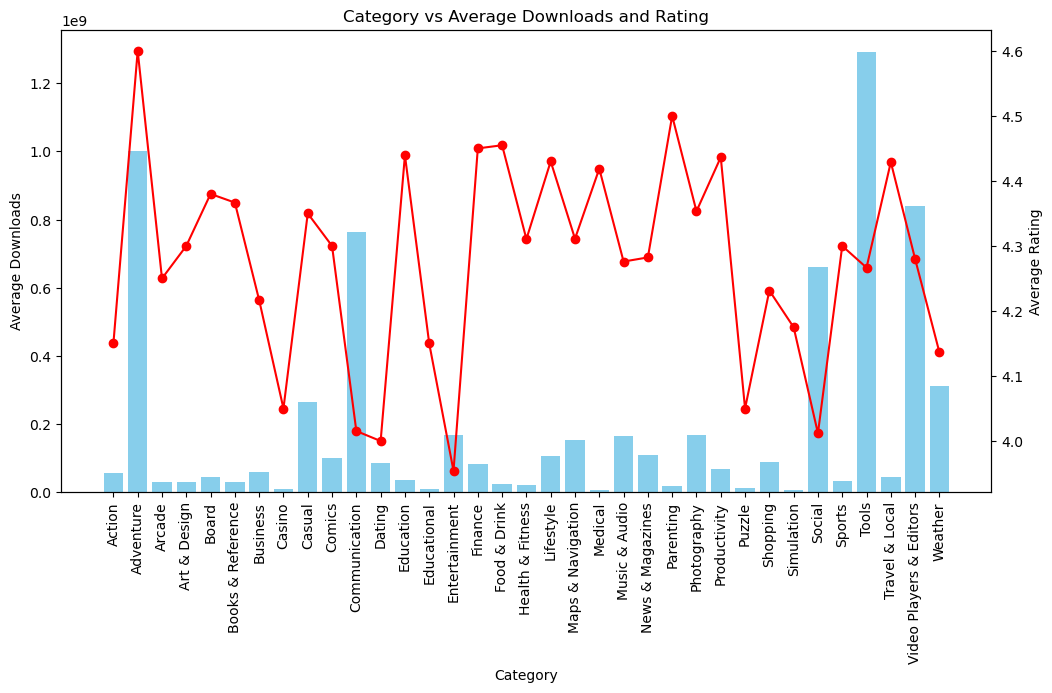

In [265]:
import matplotlib.pyplot as plt

multi = data.groupby("Category")[["Downloads", "Rating"]].mean()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(multi.index, multi["Downloads"], color="skyblue")
ax1.set_ylabel("Average Downloads")
ax1.set_xlabel("Category")
plt.xticks(rotation=90)

ax2 = ax1.twinx()
ax2.plot(multi.index, multi["Rating"], color="red", marker="o")
ax2.set_ylabel("Average Rating")

plt.title("Category vs Average Downloads and Rating")
plt.show()

In [266]:
# The chart shows that the Tools category has the highest average downloads and also has a good average rating. However, categories with higher downloads do not always have higher ratings. 
    # This indicates that app popularity and user ratings are not directly related.

# 2. Category + Reviews + Downloads


To compare average reviews and average downloads across different app categories.

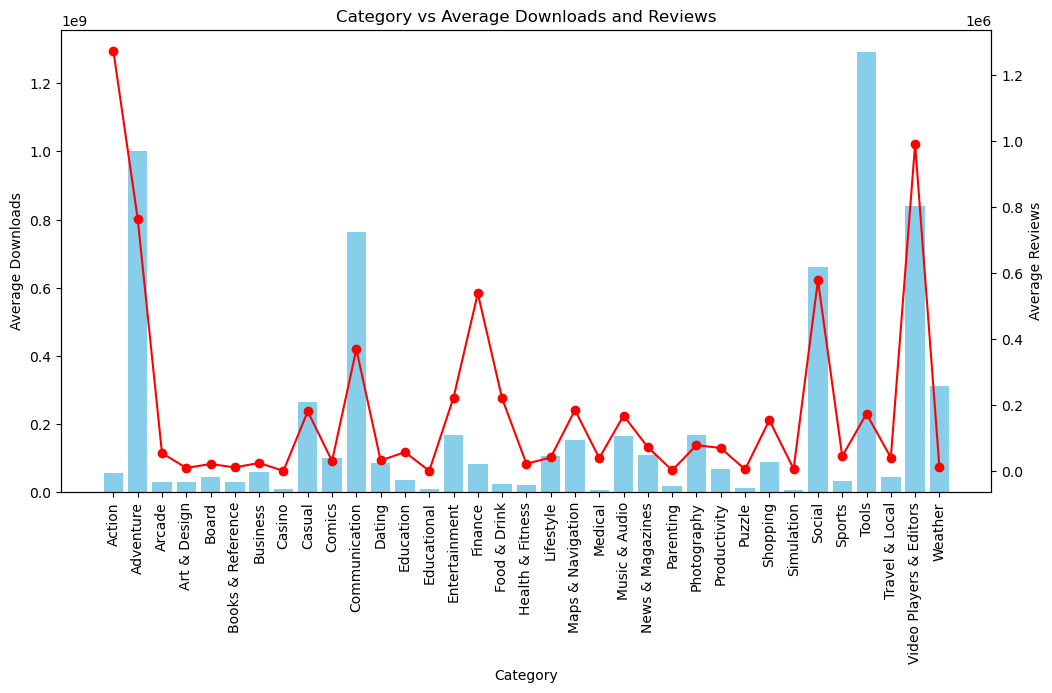

In [267]:
import matplotlib.pyplot as plt

multi = data.groupby("Category")[["Reviews", "Downloads"]].mean()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(multi.index, multi["Downloads"], color="skyblue")
ax1.set_ylabel("Average Downloads")
ax1.set_xlabel("Category")
plt.xticks(rotation=90)

ax2 = ax1.twinx()
ax2.plot(multi.index, multi["Reviews"], color="red", marker="o")
ax2.set_ylabel("Average Reviews")

plt.title("Category vs Average Downloads and Reviews")
plt.show()

In [268]:
# The chart shows that the Tools category has the highest average downloads, while the Action category has the highest average reviews. 
    # Overall, categories with higher downloads tend to receive more reviews, but this is not true for every category.

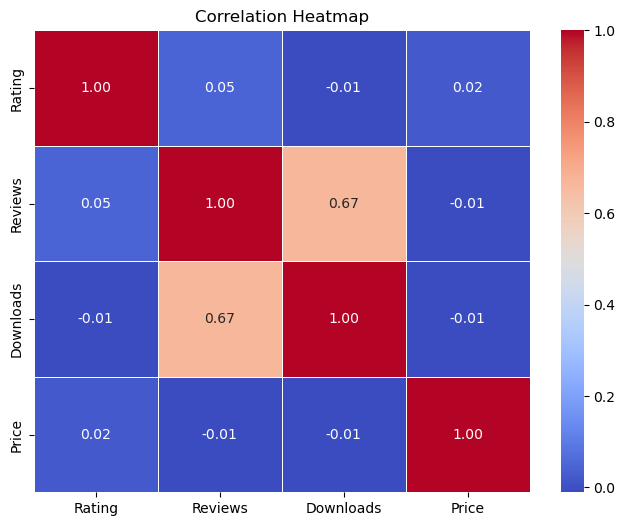

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = data.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Interpretation of Each Correlation
Variables	Correlation	Interpretation
Reviews ↔ Downloads	0.67	Moderate positive correlation. Apps with more downloads generally have more reviews.
Rating ↔ Reviews	0.05	Very weak positive correlation. Reviews have little effect on ratings.
Rating ↔ Downloads	-0.01	No meaningful relationship. Downloads do not significantly affect ratings.
Rating ↔ Price	0.02	Very weak positive correlation. Price has almost no effect on ratings.
Price ↔ Reviews	-0.01	No meaningful relationship.
Price ↔ Downloads	-0.01	No meaningful relationship.

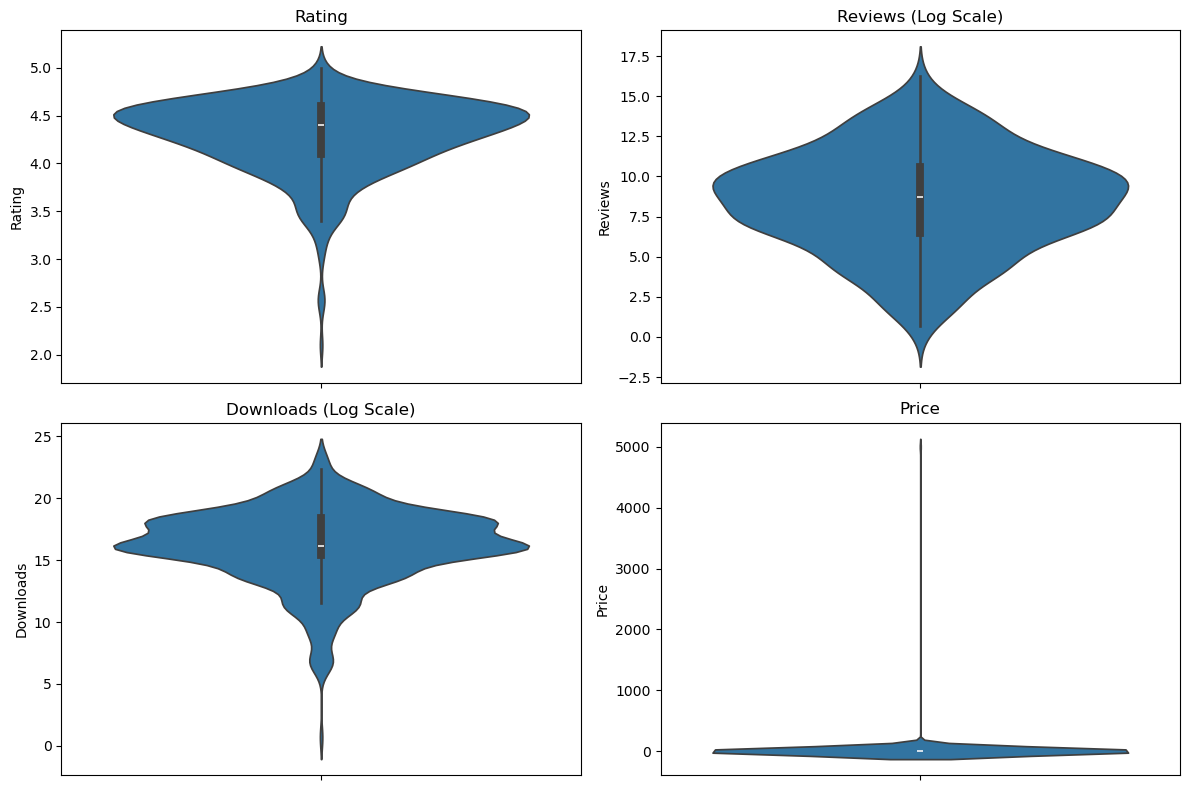

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Rating
sns.violinplot(y=data["Rating"], ax=axes[0, 0])
axes[0, 0].set_title("Rating")

# Reviews (Log Scale)
sns.violinplot(y=np.log1p(data["Reviews"]), ax=axes[0, 1])
axes[0, 1].set_title("Reviews (Log Scale)")

# Downloads (Log Scale)
sns.violinplot(y=np.log1p(data["Downloads"]), ax=axes[1, 0])
axes[1, 0].set_title("Downloads (Log Scale)")

# Price
sns.violinplot(y=data["Price"], ax=axes[1, 1])
axes[1, 1].set_title("Price")

plt.tight_layout()
plt.show()

In [ ]:
We used a log scale only for Reviews and Downloads because these variables have very large values and are highly right-skewed. 
The log scale compresses large values and spreads out smaller values, making the distribution easier to understand. Rating and Price do not need a log scale because \
Rating has a small range (1–5), and most Price values are 0 (free apps).

In [81]:
successful = data[
    (data["Rating"] >= 4.0) &
    (data["Downloads"] >= 1000000)
]

successful[["App Name", "Rating", "Downloads", "Reviews"]].head(10)

,App Name,Rating,Downloads,Reviews
4,Milkbasket,4.2,5000000,48810
5,Preglife,4.4,1000000,65
6,HideU,4.2,100000000,102343
7,Gallery,4.7,50000000,21468
9,SoundCloud,4.5,100000000,52872
10,Reddit,4.5,100000000,48770
11,Instagram,4.3,5000000000,8466697
12,Slots,4.1,10000000,332
13,iMobile,4.6,50000000,1378411
16,Yr,4.2,10000000,86


In [83]:
# Final Interpretation

In [ ]:
This project analyzed Google Play Store data to understand the characteristics of successful mobile applications. 
The analysis showed that successful apps are generally free, have high user ratings (mostly above 4.0), receive a large number of downloads and reviews, and are updated regularly.
We also found that downloads and reviews have a moderate positive relationship, while ratings are not strongly influenced by the number of downloads or the app's price.
Overall, app quality, user engagement, and regular maintenance appear to be more important factors for success than pricing alone.*

In [84]:
#  Business Insights

In [ ]:
Developers should prioritize app quality, regular updates, user engagement, and continuous improvement. 
Instead of focusing only on increasing downloads, they should aim to provide a reliable and satisfying user experience,
which ultimately leads to better ratings, more reviews, and sustained success on the Google Play Store.*